# **Taller 7**

* Nicolas Rozo Fajardo - 202112920
* Santiago Martínez Novoa - 202112020

# **0. Exploración básica de datos**

En esta sección se realiza un análisis exploratorio inicial del conjunto de datos **Pizza vs. Not Pizza**. El objetivo principal es validar la integridad de los archivos, comprender la distribución de las categorías y observar las características visuales cualitativas de las imágenes. Los aspectos clave identificados en esta exploración incluyen:

* **Balance de clases:** Se verifica que la cantidad de muestras disponibles para cada categoría ("Pizza" y "Not Pizza") es la misma, lo que indica que las clases están balanceadas dentro del conjunto de datos. Mantener un conjunto de datos equilibrado es crucial para evitar que el modelo desarrolle un sesgo hacia la clase mayoritaria, asegurando que las métricas de desempeño (como el accuracy) sean representativas.

* **Heterogeneidad de dimensiones:** Al visualizar las muestras, se evidencia que las imágenes poseen distintos tamaños y relaciones de aspecto. Esto implica que será estrictamente necesario un paso de redimensión (resizing) antes de convertir los datos en vectores de entrada para la red neuronal.

* **Variabilidad en las condiciones de captura:** Se observa una alta variabilidad en cuanto a ángulos de cámara, niveles de iluminación y fondos. Estas variaciones incluyen un nivel de complejidad adicional para la extracción de características por parte del modelo, por lo cual se deben tener en cuenta al momento de procesar las imágenes. 

* **Profundidad de color:** Las imágenes están compuestas por 3 canales (RGB), lo que inidica que se está trabajando con imágenes a color. Aunque el color añade riqueza a los datos, también aumenta las dimensiones de los mismos y, por ende, la cantidad de parámetros del modelo. Se debe evaluar si es necesario trabajar con la totalidad de los canales. 

In [1]:
import matplotlib.pyplot as plt
import random
import cv2
import os

In [2]:
DATA_DIR = "../data"

In [3]:
pizza_dir = os.path.join(DATA_DIR, "pizza")
no_pizza_dir = os.path.join(DATA_DIR, "not_pizza")

In [4]:
pizza_images = os.listdir(pizza_dir)
no_pizza_images = os.listdir(no_pizza_dir)

In [5]:
print("NUMBER OF IMAGES:\n")
print(f"PIZZA: {len(pizza_images)}")
print(f"NOT PIZZA: {len(no_pizza_images)}")

NUMBER OF IMAGES:

PIZZA: 983
NOT PIZZA: 983


In [6]:
categories = [
    c for c in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, c))
]

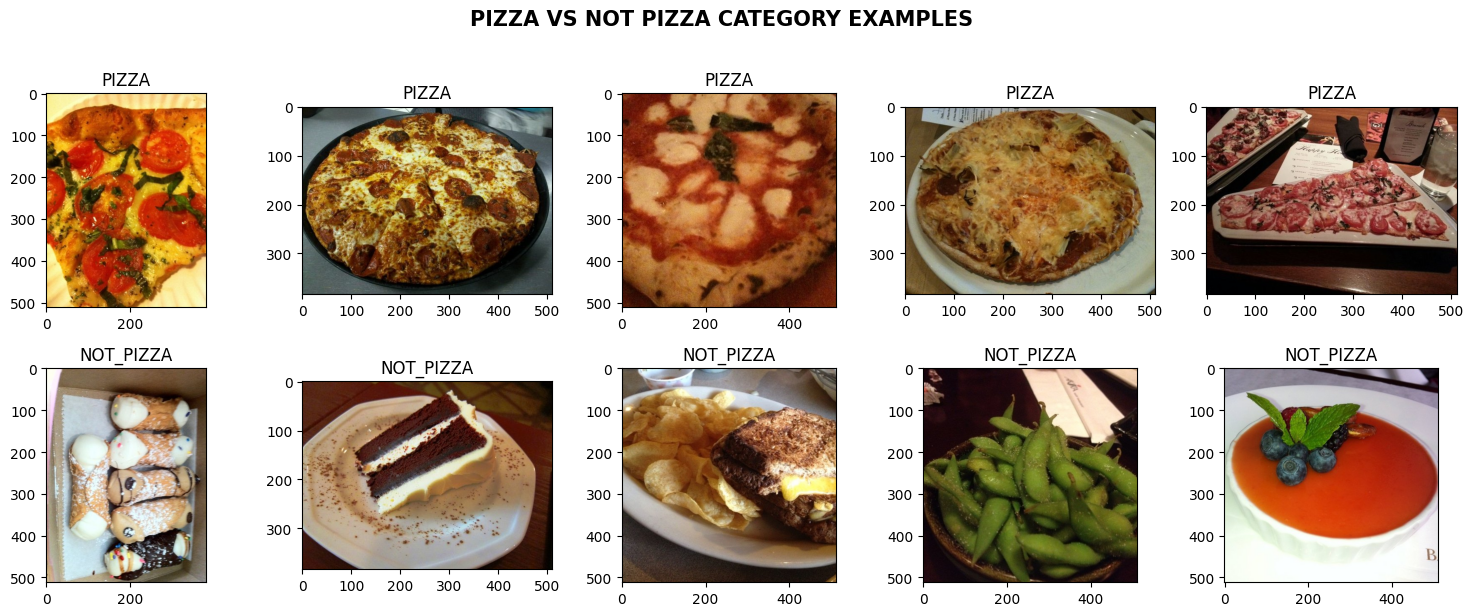

In [7]:
plt.figure(figsize = (15, 6))
plt.suptitle("PIZZA VS NOT PIZZA CATEGORY EXAMPLES", fontsize = 15, fontweight = "bold", y=1.02)
for i, category in enumerate(categories):

    folder = os.path.join(DATA_DIR, category)
    images = os.listdir(folder)

    for j in range(5):  

        img_name = random.choice(images)
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(categories), 5, i * 5 + j + 1)
        plt.imshow(img)
        plt.title(category.upper())

plt.tight_layout()
plt.show()

# **1. Preprocesamiento de datos**

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow import keras
import pandas as pd

En esta sección se implementan las técnicas de preprocesamiento necesarias para preparar las imágenes del dataset **Pizza vs. Not Pizza** antes de alimentarlas al modelo MLP. El preprocesamiento es fundamental porque las redes neuronales son sensibles a la escala, distribución y variabilidad de los datos de entrada. Un pipeline de preprocesamiento bien diseñado mejora la convergencia del entrenamiento, reduce el sobreajuste y aumenta la capacidad de generalización del modelo.

Las técnicas aplicadas incluyen:

* **Carga y organización de datos:** Estructuración mediante DataFrames para un manejo centralizado y eficiente de las rutas de archivos y sus respectivas etiquetas.

* **División estratificada:** Segmentación del conjunto de datos en conjuntos de entrenamiento, validación y prueba, garantizando que se preserve la proporción original de las clases en cada subconjunto, es decir, que sean conjuntos equilibrados.

* **Normalización:** Escalado de los valores de intensidad de los píxeles al rango [0, 1] para asegurar la estabilidad numérica y acelerar la convergencia del optimizador.

* **Conversión a escala de grises:** Reducción de la dimensionalidad de entrada a un solo canal, simplificando la complejidad del modelo y eliminando información cromática redundante.

* **Aumentación de datos:** Generación de variabilidad sintética mediante transformaciones aleatorias (rotación, desplazamiento, zoom, flip y brillo) para robustecer el entrenamiento y prevenir el sobreajuste.

In [9]:
VALID_EXTENSIONS = [".png", ".jpg", ".jpeg"]

In [10]:
filepaths = []
labels = []

for dp, dn, filenames in os.walk(DATA_DIR):
    for f in filenames:
        ext = os.path.splitext(f)[1].lower()
        
        if ext in VALID_EXTENSIONS:
            path = os.path.join(dp, f)
            label = os.path.basename(dp)
            
            filepaths.append(path)
            labels.append(label)

In [11]:
data_df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

In [12]:
print(data_df["label"].value_counts())

label
pizza        983
not_pizza    983
Name: count, dtype: int64


Como se puede confirmar con el conteo impreso, el conjunto de datos está **perfectamente balanceado** con **983** imágenes por clase, lo cual es ideal para clasificación binaria. Esto significa que no es necesario aplicar técnicas de balanceo como sobremuestreo (oversampling) o submuestreo (undersampling), y las métricas como accuracy serán representativas del desempeño real del modelo.

A continuación se divide el dataset en tres conjuntos utilizando **estratificación** (`stratify`) para mantener la proporción 50/50 entre clases en cada partición:

* **Conjunto de entrenamiento (70%):** Segmento principal de datos destinado al aprendizaje de patrones y a la actualización de los pesos y parámetros internos de la red neuronal.

* **Conjunto de validación (20%):** Fracción de datos utilizada para monitorear el rendimiento durante el entrenamiento, actuando como un control contra el sobreajuste.

* **Conjunto de prueba (10%):** Reservorio de datos no vistos diseñado para la evaluación final del modelo, permitiendo medir su capacidad real de generalización sobre datos no observados anteriormente.

In [13]:
train_df, test_val_df = train_test_split(
    data_df,
    test_size = 0.3,
    random_state = 42,
    stratify = data_df["label"]
)

test_df, val_df = train_test_split(
    test_val_df,
    test_size = 2/3,
    random_state = 42,
    stratify = test_val_df["label"]
)

In [14]:
total = len(data_df)

print(f"TOTAL IMAGES: {total}")
print(f"TRAIN:      {len(train_df)} ({(len(train_df)/total) * 100:.2f}%)")
print(f"VALIDATION: {len(val_df)} ({(len(val_df)/total) * 100:.2f}%)")
print(f"TEST:       {len(test_df)} ({(len(test_df)/total) * 100:.2f}%)")

TOTAL IMAGES: 1966
TRAIN:      1376 (69.99%)
VALIDATION: 394 (20.04%)
TEST:       196 (9.97%)


In [15]:
print("\nTRAIN DISTRIBUTION:\n")
print(train_df["label"].value_counts(normalize = True))

print("\nVALIDATION DISTRIBUTION:\n")
print(val_df["label"].value_counts(normalize = True))

print("\nTEST DISTRIBUTION:\n")
print(test_df["label"].value_counts(normalize = True))


TRAIN DISTRIBUTION:

label
not_pizza    0.5
pizza        0.5
Name: proportion, dtype: float64

VALIDATION DISTRIBUTION:

label
not_pizza    0.5
pizza        0.5
Name: proportion, dtype: float64

TEST DISTRIBUTION:

label
not_pizza    0.5
pizza        0.5
Name: proportion, dtype: float64


Se confirma que la estratificación funcionó correctamente. Los tres conjuntos mantienen una distribución 50/50 entre las clases **pizza** y **not_pizza**. Esto garantiza que ningún conjunto tenga un sesgo hacia una clase particular, lo cual es esencial para que las métricas de evaluación sean confiables y comparables entre particiones. De igual forma, se confirma que los porcentajes de división respecto al total de datos corresponden a lo esperado. 

En lo que respecta al tamaño de la imagen y el procesamiento por lotes utilizado se tomarón las sigujientes decisiones:

* **`IMG_SIZE = (64, 64)`**: Se elige un tamaño de imagen reducido (64×64 píxeles) por dos razones principales. Primero, al usar un MLP (no una CNN), cada píxel se convierte en una neurona de entrada tras el aplanamiento. Un tamaño mayor (por ejemplo 224×224) resultaría en 50,176 neuronas de entrada (en escala de grises), lo cual incrementaría enormemente el número de parámetros y el riesgo de sobreajuste. Segundo, 64×64 es suficiente para capturar las formas y texturas generales que distinguen una pizza de otro alimento.

* **`BATCH_SIZE = 64`**: Un batch de 64 muestras ofrece un buen equilibrio entre estabilidad del gradiente (más estable que batches pequeños) y eficiencia de memoria. Además, al tener aproximadamente 1376 muestras de entrenamiento, esto resulta en aproximadamente 21 pasos por época, lo cual es razonable para una convergencia suave y adecuada.

In [16]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 64

En cuanto al tratamiento de las imágenes y la configuración de los generadores de datos, se aplicaron los siguientes criterios técnicos:

* **Normalización (`rescale = 1./255`):** Se aplica a la totalidad de los datos (entrenamiento, validación y prueba) para transformar los valores de intensidad de los píxeles del rango original [0, 255] al rango [0, 1]. Esta técnica es fundamental porque las funciones de activación como ReLU o Sigmoid operan con mayor eficiencia en rangos pequeños. Además, acelera la convergencia del optimizador al evitar gradientes desproporcionadamente grandes y garantiza que ningún píxel domine el aprendizaje por su valor bruto, manteniendo todas las características en la misma escala.

* **Aumentación de datos (Data Augmentation):** Esta técnica se implementa exclusivamente en el conjunto de entrenamiento para generar variaciones sintéticas de las imágenes originales en tiempo real. Actúa como un regularizador implícito que ayuda a prevenir el sobreajuste, algo crítico dado el tamaño moderado del dataset (aproximadamente 1,376 imágenes). Las transformaciones aplicadas se detallan a continuación:

| Técnica | Configuración | Justificación |
|---|---|---|
| `rotation_range = 10` | Rotaciones aleatorias de hasta ±10° | Una pizza puede aparecer ligeramente rotada en una foto. Se mantiene un rango pequeño porque rotaciones mayores podrían distorsionar la apariencia natural del alimento. |
| `width_shift_range = 0.05` | Desplazamiento horizontal de hasta 5% | Simula variaciones en el encuadre de la foto. Un rango pequeño evita que el objeto principal salga del cuadro. |
| `height_shift_range = 0.05` | Desplazamiento vertical de hasta 5% | Misma justificación que el desplazamiento horizontal. |
| `zoom_range = 0.15` | Zoom aleatorio de hasta ±15% | Simula fotos tomadas a diferentes distancias. Un 15% es suficiente para introducir variabilidad sin perder el contexto de la imagen. |
| `horizontal_flip = True` | Reflejo horizontal aleatorio | Una pizza se ve igual volteada horizontalmente. Esta es una de las aumentaciones más seguras para imágenes de alimentos. |
| `brightness_range = [0.8, 1.2]` | Variación de brillo entre 80% y 120% | Simula diferentes condiciones de iluminación bajo las cuales se podría fotografiar un alimento. |

In [17]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 10,
    width_shift_range = 0.05,
    height_shift_range = 0.05,
    zoom_range = 0.15,
    horizontal_flip = True,
    brightness_range = [0.8, 1.2]
)


test_val_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale = 1./255
)

* **Conversión a escala de grises (`color_mode = "grayscale"`):** Las imágenes se procesan en un solo canal para optimizar la arquitectura del modelo. Esta decisión reduce la dimensionalidad de entrada de 12,288 a 4,096 características, lo que disminuye significativamente el número de parámetros y el riesgo de sobreajuste en un MLP. Al eliminar el color, se obliga a la red a concentrarse en patrones morfológicos y texturas (como la forma circular de la masa o la porosidad del queso), que resultan más discriminativos y menos ruidosos que la información cromática para este tipo de red.

* **Configuración de generadores (`flow_from_dataframe`):** Se utilizan generadores para automatizar la carga de imágenes en lotes (batches) directamente desde el disco, lo que optimiza el consumo de memoria RAM. El parámetro class_mode = "binary" asegura la generación de etiquetas 0 y 1, las cuales son compatibles con la función de pérdida binary_crossentropy que se utilizará para entrenar este clasificador binario.

In [18]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col = "filepath",
    y_col = "label",
    target_size = IMG_SIZE,
    color_mode = "grayscale",   
    batch_size = BATCH_SIZE,
    class_mode = "binary"
)

val_gen = test_val_datagen.flow_from_dataframe(
    val_df,
    x_col = "filepath",
    y_col = "label",
    target_size = IMG_SIZE,
    color_mode = "grayscale",   
    batch_size = BATCH_SIZE,
    class_mode = "binary",
    shuffle = False
)

test_gen = test_val_datagen.flow_from_dataframe(
    test_df,
    x_col = "filepath",
    y_col = "label",
    target_size = IMG_SIZE,
    color_mode = "grayscale",   
    batch_size = BATCH_SIZE,
    class_mode = "binary",
    shuffle = False
)

Found 1376 validated image filenames belonging to 2 classes.
Found 394 validated image filenames belonging to 2 classes.
Found 196 validated image filenames belonging to 2 classes.


# **2. Construcción de un modelo de red neuronal perceptrón multicapa**

In [19]:
from keras.layers import Dense, Flatten, Dropout
from keras.models import Sequential
from keras.optimizers import Adam

En esta sección se construye un modelo de **Perceptrón Multicapa (MLP)** para la tarea de clasificación binaria **pizza vs no-pizza**. A diferencia de las CNNs, un MLP no posee capas convolucionales que extraigan características espaciales automáticamente. En su lugar, recibe los píxeles aplanados como un vector de entrada y aprende relaciones globales entre todos los píxeles mediante capas densamente conectadas.

La arquitectura propuesta del MLP sigue un diseño de **embudo decreciente** (4096 → 128 → 64 → 1), donde cada capa reduce progresivamente la dimensionalidad, forzando al modelo a aprender representaciones cada vez más abstractas y compactas.

| Capa | Detalles | Justificación |
|---|---|---|
| **Flatten** | Entrada: (64, 64, 1) → Salida: (4096,) | Convierte la imagen 2D en un vector 1D para alimentar las capas densas. Es el paso necesario para que un MLP procese imágenes. |
| **Dense(128, ReLU)** | 4096 → 128 neuronas | Primera capa oculta. 128 neuronas ofrecen capacidad suficiente para aprender patrones relevantes sin ser excesivo (evitando sobreajuste). **ReLU** se elige como activación porque es computacionalmente eficiente, mitiga el problema del gradiente desvaneciente, e introduce no-linealidad permitiendo al modelo aprender fronteras de decisión complejas. |
| **Dropout(0.4)** | 40% de las neuronas desactivadas aleatoriamente | Técnica de regularización que previene el sobreajuste al obligar a la red a no depender excesivamente de neuronas específicas. Se usa un valor relativamente alto (0.4) después de la capa más grande para mayor efecto regularizador. |
| **Dense(64, ReLU)** | 128 → 64 neuronas | Segunda capa oculta. Reduce la dimensionalidad a la mitad, forzando una representación más compacta. Mantiene la activación ReLU por consistencia y eficiencia. |
| **Dropout(0.3)** | 30% de las neuronas desactivadas | Dropout ligeramente menor que la capa anterior, ya que esta capa tiene menos neuronas y un dropout muy agresivo podría limitar excesivamente la capacidad del modelo. |
| **Dense(1, Sigmoid)** | 64 → 1 neurona | Capa de salida para clasificación binaria. La función **Sigmoid** mapea la salida al rango (0, 1), interpretable como la probabilidad de pertenecer a la clase positiva (*pizza*). Un umbral de 0.5 se usa para la decisión final. |

Cabe resaltar que se decide utilizar solo dos capas ocultas ya que, debido al tamaño reducido del conjunto de datos y a que se esta llevando a cabo una tarea de clasificación binaria, la cual es relativamente simple, una red más profunda tendría mayor riesgo de sobreajuste sin una mejora significativa en capacidad de representación. Dos capas ocultas proporcionan suficiente profundidad para aprender patrones no lineales complejos según el teorema de aproximación universal.

In [ ]:
model = Sequential([

    Flatten(input_shape=(64, 64, 1)), 
    
    Dense(128, activation = "relu"),
    Dropout(0.4),
    
    Dense(64, activation = "relu"),
    Dropout(0.3),
    
    Dense(1, activation = "sigmoid")  

])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,737 (2.03 MB)

 Trainable params: 532,737 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

En lo que respecta a la compilación del modelo creado, se tomarón las siguientes decisiones: 

* **Optimizador: Adam (`learning_rate = 0.0005`):** Adam combina las ventajas de **RMSProp** y **Momentum**, adaptando la tasa de aprendizaje individualmente para cada parámetro. Se elige una tasa de aprendizaje de 0.0005 (menor que el default de 0.001) para una convergencia más suave y estable, reduciendo el riesgo de que el modelo oscile alrededor del mínimo.

* **Función de pérdida: `binary_crossentropy`:** Es la función estándar para clasificación binaria con salida sigmoide. Mide la divergencia entre la distribución predicha y la real, penalizando más las predicciones confiantes pero incorrectas.

* **Métrica: `accuracy`:** Dado que el dataset está balanceado (50/50), la accuracy es una métrica representativa durante el entrenamiento. Métricas adicionales como precision, recall y F1-score se evaluarán en la fase de prueba.

In [22]:
model.compile(
    optimizer = Adam(learning_rate = 0.0005),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

# **3. Definición de funciones callback para monitorear el entrenamiento**

In [23]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

Los **callbacks** en Keras son funciones que se ejecutan en puntos específicos durante el entrenamiento (al inicio/fin de cada época, batch, etc.). Son herramientas esenciales para:

* **Detectar sobreajuste:** Al monitorear la divergencia entre las métricas calculadas sobre los conjuntos de entrenamiento y validación, estas funciones permiten detectar sobreajustes sobre la marcha. 

* **Detener el entrenamiento automáticamente:** Cuando el modelo dejar de mejorar significativamente o se estanca por varias épocas, estas funciones nos permiten detener el entrenamiento, lo que ahorra tiempo y recursos computacionales. 

* **Guardar el mejor modelo:** Permiten guardar el mejor modelo obtenido durante el entrenamiento con respecto a una métrica de control. Esto garantiza que no se pierda el mejor modelo, aún si no es el que ocurre en la última época. 

* **Ajustar hiperparámetros dinámicamente:** Permite ajustar hiperparámetros como la tasa de aprendizaje teniendo en cuenta el avance de las métricas durante el entrenamiento. 

In [24]:
model_checkpoint = ModelCheckpoint(
    "../models/best_model.h5",
    monitor = "val_loss",
    mode = "min",
    save_best_only = True,
    verbose = 1
)

early_stopping = EarlyStopping(
    monitor = "val_loss",
    patience = 10,              
    mode = "min",
    restore_best_weights = True,  
    verbose = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor = "val_loss",
    factor = 0.2,              
    patience = 4,              
    min_lr = 1e-7,
    mode = "min",
    verbose = 1
)

En lo que respecta a los **callbacks** utilizados, se tomaron las siguientes decisiones:

**1. ModelCheckpoint:**

- **Qué hace:** Guarda el modelo al archivo `best_model.h5` cada vez que la `val_loss` alcanza un nuevo mínimo.
- **Por qué es útil:** Durante el entrenamiento, el modelo puede alcanzar su mejor desempeño en una época intermedia y luego comenzar a sobreajustar. Sin este callback, al finalizar el entrenamiento solo tendríamos acceso al modelo de la última época (posiblemente sobreajustado). `save_best_only=True` garantiza que siempre tengamos acceso al mejor modelo observado.
- **Cómo ayuda a identificar problemas:** Si el modelo guardado corresponde a una época muy temprana, podría indicar que el modelo comienza a sobreajustar rápidamente.

**2. EarlyStopping:**

- **Qué hace:** Detiene el entrenamiento si la `val_loss` no mejora durante 10 épocas consecutivas (`patience=10`).
- **Por qué es útil:** Previene tanto el sobreajuste (entrenar más allá del punto óptimo) como el desperdicio de recursos computacionales. `restore_best_weights=True` asegura que al finalizar, el modelo tenga los pesos de la mejor época, no de la última.
- **Cómo ayuda a identificar problemas:**
  - Si se detiene muy pronto (pocas épocas): podría indicar que la tasa de aprendizaje es demasiado alta o que la arquitectura no es adecuada.
  - Si nunca se activa (llega a las 50 épocas): podría indicar que `patience` es demasiado alto o que el modelo aún está aprendiendo y se podrían necesitar más épocas.

**3. ReduceLROnPlateau:**
- **Qué hace:** Reduce la tasa de aprendizaje por un factor de 0.2 (la divide por 5) si la `val_loss` no mejora durante 4 épocas consecutivas. El learning rate mínimo permitido es 1e-7.
- **Por qué es útil:** Cuando el modelo se acerca a un mínimo, una tasa de aprendizaje alta puede causar oscilaciones alrededor del mínimo sin converger. Reducir el LR permite pasos más pequeños y finos, facilitando la convergencia precisa.
- **Cómo ayuda a identificar problemas:** Si el LR se reduce múltiples veces rápidamente, puede indicar que el modelo está estancado en un mínimo local o que la arquitectura ha alcanzado su capacidad máxima para este problema.
- **Interacción con EarlyStopping:** `patience=4` para ReduceLR < `patience=10` para EarlyStopping. Esto permite que primero se reduzca el LR (dándole al modelo una oportunidad de mejorar con pasos más pequeños) antes de decidir detener el entrenamiento.

In [25]:
callbacks = [model_checkpoint, early_stopping, reduce_lr]

# **4. Entrenamiento y exploración de resultados**

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
from keras.models import load_model
import tensorflow as tf
import seaborn as sns
import numpy as np

En esta sección se entrena el modelo compilando anteriormente y se analizan los resultados obtenidos. En lo que respecta a la configuración del proceso de entrenamiento, se tomarón las siguientes decisiones:

* **Épocas máximas (50):** Se establece un número máximo generoso de épocas, confiando en que `EarlyStopping` detendrá el entrenamiento en el momento adecuado.

* **Dispositivo (GPU):** Se utiliza `tf.device("/device:GPU:0")` para aprovechar la aceleración por hardware, reduciendo significativamente el tiempo de entrenamiento.

* **Datos de validación:** Se pasan al método `fit()` para que Keras calcule las métricas de validación al final de cada época, permitiendo a los callbacks monitorear el progreso.

In [27]:
with tf.device("/device:GPU:0"):
    history = model.fit(
        train_gen,
        validation_data = val_gen,
        epochs = 50,
        callbacks = callbacks,
        verbose = 1
    )

Epoch 1/50


I0000 00:00:1776012824.568029   29370 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4821 - loss: 0.7831
Epoch 1: val_loss improved from None to 0.66667, saving model to ../models/best_model.h5



Epoch 1: finished saving model to ../models/best_model.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.5007 - loss: 0.7771 - val_accuracy: 0.6371 - val_loss: 0.6667 - learning_rate: 5.0000e-04
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5204 - loss: 0.7279
Epoch 2: val_loss did not improve from 0.66667
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.5378 - loss: 0.7026 - val_accuracy: 0.6142 - val_loss: 0.6755 - learning_rate: 5.0000e-04
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5479 - loss: 0.6882
Epoch 3: val_loss improved from 0.66667 to 0.66427, saving model to ../models/best_model.h5



Epoch 3: finished saving model to ../models/best_model.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.5436 - loss: 0.6902 - val_accuracy: 0.6548 - val_loss: 0.6643 - learning_rate: 5.0000e-04
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5471 - loss: 0.6933
Epoch 4: val_loss did not improve from 0.66427
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.5334 - loss: 0.6891 - val_accuracy: 0.5787 - val_loss: 0.6660 - learning_rate: 5.0000e-04
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5979 - loss: 0.6715
Epoch 5: val_loss improved from 0.66427 to 0.66078, saving model to ../models/best_model.h5


...


Epoch 14: finished saving model to ../models/best_model.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.5879 - loss: 0.6626 - val_accuracy: 0.6650 - val_loss: 0.6458 - learning_rate: 5.0000e-04
Epoch 15/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6298 - loss: 0.6615
Epoch 15: val_loss did not improve from 0.64579
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.6076 - loss: 0.6597 - val_accuracy: 0.6142 - val_loss: 0.6563 - learning_rate: 5.0000e-04
Epoch 16/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5840 - loss: 0.6678
Epoch 16: val_loss improved from 0.64579 to 0.64536, saving model to ../models/best_model.h5



Epoch 16: finished saving model to ../models/best_model.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.5952 - loss: 0.6652 - val_accuracy: 0.6447 - val_loss: 0.6454 - learning_rate: 5.0000e-04
Epoch 17/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5861 - loss: 0.6694
Epoch 17: val_loss did not improve from 0.64536
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.5923 - loss: 0.6609 - val_accuracy: 0.6523 - val_loss: 0.6517 - learning_rate: 5.0000e-04
Epoch 18/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5957 - loss: 0.6674
Epoch 18: val_loss did not improve from 0.64536
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.5981 - loss: 0.6639 - val_accuracy: 0.6396 - val_loss: 0.6500 - learning_rate: 5.0000e-04
Epoch 19/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6293 - loss: 0.6522
Epoch 19: val_loss did not improve from 0.64536
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.5996 - loss: 0.6649 - val_accuracy: 0.6244 - val_los


Epoch 20: finished saving model to ../models/best_model.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.6126 - loss: 0.6542 - val_accuracy: 0.6523 - val_loss: 0.6428 - learning_rate: 5.0000e-04
Epoch 21/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6165 - loss: 0.6575
Epoch 21: val_loss improved from 0.64279 to 0.64265, saving model to ../models/best_model.h5



Epoch 21: finished saving model to ../models/best_model.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.6047 - loss: 0.6578 - val_accuracy: 0.6497 - val_loss: 0.6426 - learning_rate: 5.0000e-04
Epoch 22/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5998 - loss: 0.6567
Epoch 22: val_loss improved from 0.64265 to 0.63557, saving model to ../models/best_model.h5



Epoch 22: finished saving model to ../models/best_model.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.6097 - loss: 0.6555 - val_accuracy: 0.6726 - val_loss: 0.6356 - learning_rate: 5.0000e-04
Epoch 23/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6025 - loss: 0.6578
Epoch 23: val_loss did not improve from 0.63557
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.5916 - loss: 0.6586 - val_accuracy: 0.6396 - val_loss: 0.6496 - learning_rate: 5.0000e-04
Epoch 24/50
21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5822 - loss: 0.6662
Epoch 24: val_loss did not improve from 0.63557
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.5974 - loss: 0.6593 - val_accuracy: 0.6320 - val_loss: 0.6538 - learning_rate: 5.0000e-04
Epoch 25/50
21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5873 - loss: 0.6613
Epoch 25: val_loss did not improve from 0.63557
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.5850 - loss: 0.6644 - val_accuracy: 0.6497 - val_los

Para analizar la calidad del proceso de entrenamiento y detectar posibles problemas o patrones, se grafica la evolución tanto del **loss** como del **accuracy** sobre los conjuntos de entrenamiento y validación. Esta gráfica se realiza con respecto a las epocas de entrenamiento, ya que de esa forma se puede visualizar el comportamiento y su avance. 

In [28]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

In [29]:
epochs_range = range(len(acc))

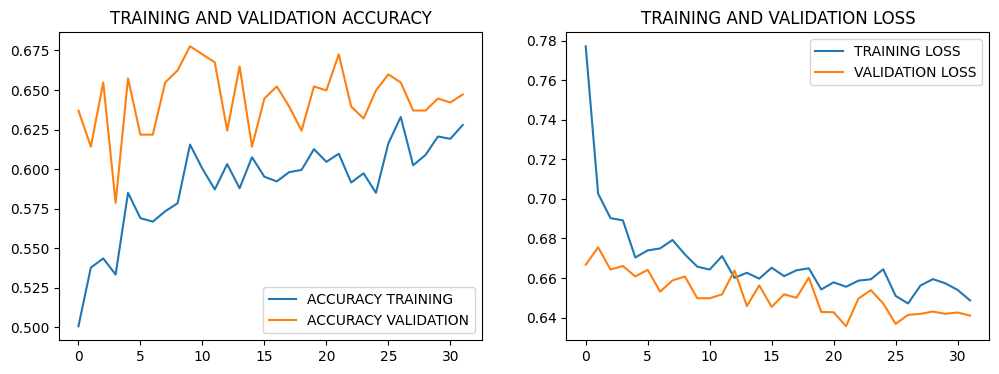

In [30]:
plt.figure(figsize = (12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label = "ACCURACY TRAINING")
plt.plot(epochs_range, val_acc, label = "ACCURACY VALIDATION")
plt.legend(loc = "lower right")
plt.title("TRAINING AND VALIDATION ACCURACY")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label = "TRAINING LOSS")
plt.plot(epochs_range, val_loss, label = "VALIDATION LOSS")
plt.legend(loc = "upper right")
plt.title("TRAINING AND VALIDATION LOSS")
plt.show()

Las gráficas anteriores permiten diagnosticar el comportamiento del modelo durante el entrenamiento:

* **Curvas de Accuracy:** Se observa que el accuracy de entrenamiento y validación convergen y se mantienen relativamente cercanos, lo cual es una señal positiva de que el modelo no presenta un sobreajuste severo. Las técnicas de regularización (Dropout, aumentación de datos) están cumpliendo su función.

* **Curvas de Loss:** La pérdida de entrenamiento disminuye de forma consistente. La pérdida de validación también disminuye pero con más ruido (fluctuaciones), lo cual es normal dado el tamaño del conjunto de validación. El callback `ReduceLROnPlateau` probablemente intervino para suavizar la convergencia cuando la val_loss se estancó.

Una vez analizadas las métricas de entrenamiento, se carga el **mejor modelo** guardado por `ModelCheckpoint` para la evaluación final, garantizando que se evalúa el modelo en su punto óptimo de entrenamiento y no en su última época.

In [ ]:
best_model = load_model("../models/best_model.h5")

Sobre el mejor modelo se lleva a cabo el proceso de evaluación final, el cual consiste en realizar las predicciones sobre el conjunto de prueba y contrastar esos valores contra las etiquetas del mismo. 

In [32]:
test_gen.reset()
predictions = best_model.predict(test_gen, verbose = 1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [33]:
y_pred = (predictions > 0.5).astype(int).reshape(-1)
y_test = test_gen.classes

La matriz de confusión permite visualizar los aciertos y errores del modelo por clase. Los elementos de la diagonal principal representan las predicciones correctas (verdaderos positivos y verdaderos negativos), mientras que los elementos fuera de la diagonal representan los errores (falsos positivos y falsos negativos). Un modelo ideal tendría valores altos en la diagonal y ceros fuera de ella.

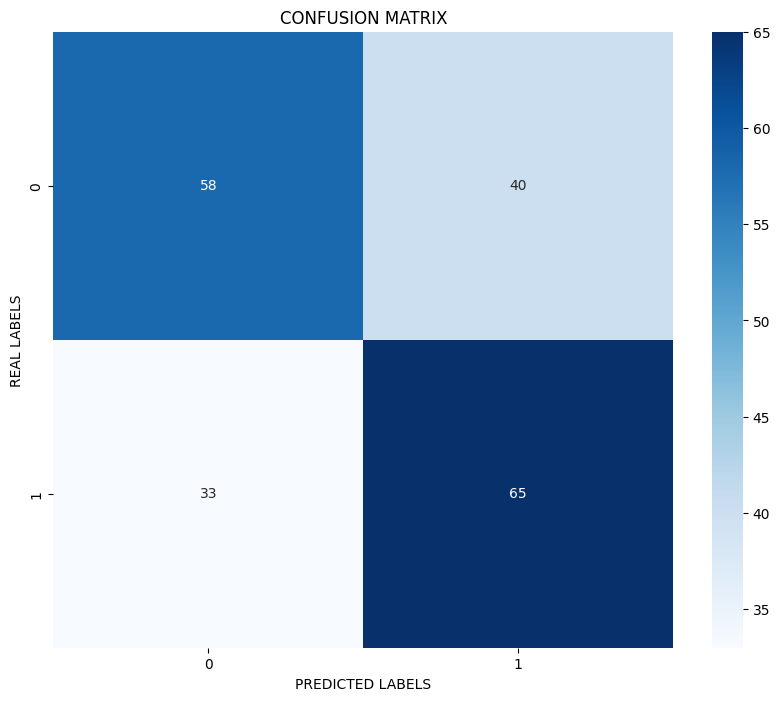

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (10, 8))

sns.heatmap(cm, annot = True, fmt = "d", cmap = plt.cm.Blues)

plt.title("CONFUSION MATRIX")
plt.ylabel("REAL LABELS")
plt.xlabel("PREDICTED LABELS")

plt.show()

In [35]:
class_names = list(test_gen.class_indices.keys())

print(classification_report(y_test, y_pred, target_names = class_names))

              precision    recall  f1-score   support

   not_pizza       0.64      0.59      0.61        98
       pizza       0.62      0.66      0.64        98

    accuracy                           0.63       196
   macro avg       0.63      0.63      0.63       196
weighted avg       0.63      0.63      0.63       196



El reporte de clasificación muestra las siguientes métricas para cada clase:

* **Precision (Precisión):** De todas las predicciones positivas para una clase, ¿cuántas fueron correctas? Una precision de ~0.63 indica que cuando el modelo predice "pizza" o "not_pizza", acierta aproximadamente el 63% de las veces.

* **Recall (Sensibilidad):** De todas las instancias reales de una clase, ¿cuántas fueron detectadas? Valores similares entre clases (~0.59-0.66) indican que el modelo no tiene un sesgo fuerte hacia una clase en particular.

* **F1-Score:** Media armónica entre precision y recall. Con valores de ~0.61-0.64, el modelo muestra un desempeño equilibrado pero modesto.

* **Accuracy global: ~63%.** Está por encima del 50% (clasificador aleatorio para clases balanceadas), lo que confirma que el modelo aprendió patrones útiles, pero hay margen significativo de mejora.

# **5. Oportunidades de mejora**

El accuracy de 63% refleja una **limitación inherente de la arquitectura MLP para tareas de visión por computadora**. Dentro de las posibles mejoras que se pueden llevar a cabo se incluyen:

1. **Usar una CNN:** Las redes convolucionales capturan patrones espaciales locales (bordes, texturas, formas) que un MLP no puede detectar al aplanar la imagen. Esta sería la mejora más impactante, ya que mantiene las relaciones espaciales inherentes de las imágenes.

2. **Usar imágenes en color (RGB):** Si bien la escala de grises reduce dimensionalidad, el color podría ser discriminativo (queso amarillo, salsa roja) y una CNN podría aprovecharlo eficientemente. Específicamente en el caso de la red construida, las pruebas realizadas respetando el color de las imágenes no mostraron mejoras significativas, por lo cual no se aplicó esta técnica. 

3. **Aumentar el tamaño de imagen:** Un tamaño mayor (128×128 o 224×224) preservaría más detalles, aunque requeriría una arquitectura más adecuada (CNN) para no incrementar excesivamente los parámetros.

4. **Transfer Learning:** Usar un modelo pre-entrenado (como MobileNet o ResNet) como extractor de características y entrenar solo las capas finales, lo cual es especialmente útil con datasets pequeños.

5. **Ajuste de hiperparámetros:** Experimentar con diferentes tasas de aprendizaje, número de neuronas, número de capas y tasas de Dropout mediante búsqueda por cuadrícula o aleatoria.

A pesar de estas limitaciones, el modelo MLP cumple su propósito pedagógico al demostrar los fundamentos de clasificación de imágenes con redes neuronales, y los resultados obtenidos (63% accuracy) son razonables dadas las restricciones de la arquitectura.